# Supply Chain Performance Intelligence
### Identifying Delivery Bottlenecks, Late Shipment Risk, and Cost Drivers

**Author:** Phu Qui (Will) Dang  
**Date:** June 2026  
**Dataset:** DataCo Smart Supply Chain Dataset — 180,519 orders, 53 features  
**Tools:** Python, pandas, SQL, SQLite, scikit-learn, Tableau Public

---

## Project Overview

This notebook contains the complete analytical workflow for a supply chain performance analysis project. The goal is to identify where delivery failures occur, quantify their financial impact, and build a predictive model to identify late delivery risk factors.

**Three business questions guide this analysis:**
1. Which shipping modes and product categories carry the highest late delivery rate, and what is the financial impact?
2. Which customer markets generate the most revenue but experience the worst delivery performance?
3. Can late deliveries be predicted before shipment, and what are the top risk factors?

---

## Phase 1: Data Understanding

Before writing any code, the first step is to understand the structure, quality, and limitations of the dataset. This phase identifies data quality issues that must be resolved before any analysis begins.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')

# Basic overview
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 50)
print("FIRST 3 ROWS")
print("=" * 50)
df.head(3)

DATASET SHAPE
Rows: 180,519
Columns: 53

COLUMN NAMES AND DATA TYPES
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                     

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


**Key data quality findings:**

Product Description is 100% missing across all 180,519 rows and provides no analytical value. This column will be removed entirely.

Order Zipcode is 86% missing, making geographic analysis at postcode level unreliable. This column will also be removed.

Date columns for order date and shipping date are stored as text rather than datetime format. Converting these is essential for any time-based trend analysis.

Customer personal data including email, password, name, and street address is not relevant to delivery performance analysis and will be removed to keep the dataset focused on operational variables.

These findings inform every cleaning decision in Phase 2 below.

---

## Phase 2: Data Cleaning

Every cleaning decision below is documented with business justification. The goal is to transform the raw dataset into a clean, analysis-ready format without losing any rows.

In [ ]:
# ============================================
# PHASE 2 - DATA CLEANING
# ============================================

# Step 1: Drop irrelevant and unusable columns
cols_to_drop = [
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Product Image',
    'Product Description',
    'Order Zipcode',
    'Customer Zipcode'
]

df_clean = df.drop(columns=cols_to_drop)
print(f"Columns after dropping: {df_clean.shape[1]}")
print(f"Columns removed: {len(cols_to_drop)}")

# Step 2: Fix date columns
df_clean['order_date'] = pd.to_datetime(
    df_clean['order date (DateOrders)'],
    format='mixed'
)
df_clean['shipping_date'] = pd.to_datetime(
    df_clean['shipping date (DateOrders)'],
    format='mixed'
)

# Step 3: Extract time features
df_clean['order_year'] = df_clean['order_date'].dt.year
df_clean['order_month'] = df_clean['order_date'].dt.month
df_clean['order_quarter'] = df_clean['order_date'].dt.quarter

# Step 4: Create delivery gap feature
# Positive = delivered later than scheduled (bad)
# Negative = delivered earlier than scheduled (good)
df_clean['delivery_gap'] = (
    df_clean['Days for shipping (real)'] -
    df_clean['Days for shipment (scheduled)']
)

# Step 5: Rename columns for easier use
df_clean = df_clean.rename(columns={
    'Days for shipping (real)': 'days_shipping_real',
    'Days for shipment (scheduled)': 'days_shipping_scheduled',
    'Benefit per order': 'benefit_per_order',
    'Sales per customer': 'sales_per_customer',
    'Delivery Status': 'delivery_status',
    'Late_delivery_risk': 'late_delivery_risk',
    'Category Name': 'category_name',
    'Customer City': 'customer_city',
    'Customer Country': 'customer_country',
    'Customer Segment': 'customer_segment',
    'Customer State': 'customer_state',
    'Department Name': 'department_name',
    'Market': 'market',
    'Order City': 'order_city',
    'Order Country': 'order_country',
    'Order Region': 'order_region',
    'Order Status': 'order_status',
    'Order Profit Per Order': 'profit_per_order',
    'Product Name': 'product_name',
    'Product Price': 'product_price',
    'Shipping Mode': 'shipping_mode',
    'Sales': 'sales'
})

# Step 6: Verify clean dataset
print("\n" + "="*50)
print("CLEAN DATASET SUMMARY")
print("="*50)
print(f"Shape: {df_clean.shape}")
print(f"\nMissing values remaining:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print(f"\nNew columns created:")
print(['order_year', 'order_month', 'order_quarter', 'delivery_gap'])
print(f"\nDelivery gap stats:")
print(df_clean['delivery_gap'].describe())

Columns after dropping: 44
Columns removed: 9

CLEAN DATASET SUMMARY
Shape: (180519, 50)

Missing values remaining:
Series([], dtype: int64)

New columns created:
['order_year', 'order_month', 'order_quarter', 'delivery_gap']

Delivery gap stats:
count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delivery_gap, dtype: float64


The dataset is now clean and ready for analysis. Nine irrelevant columns were removed, date fields were converted to datetime format, and a new Delivery Gap feature was engineered to measure the difference between actual and scheduled delivery days. A positive delivery gap means the order arrived later than promised.

The average delivery gap of 0.57 days confirms that orders are systematically arriving late across the entire supply chain, not just in isolated cases.

---

## Phase 3: SQL Analysis

Loading the clean dataset into a SQLite database enables structured, reproducible queries to answer each business question. SQL is used here because it allows precise aggregation across 180,519 rows and produces results that are easy to audit and explain to business stakeholders.

In [ ]:
# Save clean dataset
df_clean.to_csv('supply_chain_clean.csv', index=False)
print("Clean dataset saved successfully")
print(f"File size: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

# Preview key columns we'll use for SQL analysis
key_cols = [
    'shipping_mode',
    'delivery_status',
    'late_delivery_risk',
    'days_shipping_real',
    'days_shipping_scheduled',
    'delivery_gap',
    'sales',
    'profit_per_order',
    'market',
    'order_region',
    'category_name',
    'customer_segment',
    'order_year',
    'order_month'
]

print("\nKey columns preview:")
print(df_clean[key_cols].head(3))

print("\nDelivery Status distribution:")
print(df_clean['delivery_status'].value_counts())

print("\nShipping Mode distribution:")
print(df_clean['shipping_mode'].value_counts())

print("\nMarket distribution:")
print(df_clean['market'].value_counts())

print("\nOverall Late Delivery Rate:")
late_rate = df_clean['late_delivery_risk'].mean() * 100
print(f"{late_rate:.1f}%")

Clean dataset saved successfully
File size: 180,519 rows x 50 columns

Key columns preview:
    shipping_mode   delivery_status  late_delivery_risk  days_shipping_real  \
0  Standard Class  Advance shipping                   0                   3   
1  Standard Class     Late delivery                   1                   5   
2  Standard Class  Shipping on time                   0                   4   

   days_shipping_scheduled  delivery_gap   sales  profit_per_order  \
0                        4            -1  327.75         91.250000   
1                        4             1  327.75       -249.089996   
2                        4             0  327.75       -247.779999   

         market    order_region   category_name customer_segment  order_year  \
0  Pacific Asia  Southeast Asia  Sporting Goods         Consumer        2018   
1  Pacific Asia      South Asia  Sporting Goods         Consumer        2018   
2  Pacific Asia      South Asia  Sporting Goods         Consumer      

In [ ]:
# ============================================
# LOAD DATA INTO SQLITE (runs inside Colab)
# ============================================
import sqlite3
from sqlalchemy import create_engine

# Create SQLite database file in Colab
engine = create_engine('sqlite:///supply_chain.db')

# Load data into SQLite
print("Loading data into SQLite database...")
df_clean.to_sql(
    'supply_chain',
    engine,
    if_exists='replace',
    index=False,
    chunksize=1000
)

print("✅ Data loaded successfully into SQLite")
print(f"Database file: supply_chain.db")
print(f"Table: supply_chain")
print(f"Rows: {len(df_clean):,}")

# Verify by running a quick test query
with engine.connect() as conn:
    result = conn.execute(
        __import__('sqlalchemy').text(
            "SELECT COUNT(*) as total_rows FROM supply_chain"
        )
    )
    print(f"\nVerification query result: {result.fetchone()[0]:,} rows in database")

Loading data into SQLite database...
✅ Data loaded successfully into SQLite
Database file: supply_chain.db
Table: supply_chain
Rows: 180,519

Verification query result: 180,519 rows in database


In [ ]:
# ============================================
# PHASE 3 - SQL ANALYSIS
# ============================================
import pandas as pd
from sqlalchemy import text

def run_query(sql, title):
    """Helper function to run SQL and display results"""
    print(f"\n{'='*60}")
    print(f"QUERY: {title}")
    print('='*60)
    with engine.connect() as conn:
        result = pd.read_sql(text(sql), conn)
    print(result.to_string(index=False))
    return result

# ── Q1A: Late delivery rate by shipping mode ──
q1a = run_query("""
    SELECT
        shipping_mode,
        COUNT(*) as total_orders,
        SUM(late_delivery_risk) as late_orders,
        ROUND(SUM(late_delivery_risk) * 100.0 / COUNT(*), 1) as late_rate_pct,
        ROUND(AVG(profit_per_order), 2) as avg_profit,
        ROUND(AVG(CASE WHEN late_delivery_risk = 1
              THEN profit_per_order END), 2) as avg_profit_when_late,
        ROUND(AVG(CASE WHEN late_delivery_risk = 0
              THEN profit_per_order END), 2) as avg_profit_when_ontime
    FROM supply_chain
    GROUP BY shipping_mode
    ORDER BY late_rate_pct DESC
""", "Q1A: Late Delivery Rate by Shipping Mode")

# ── Q1B: Late delivery rate by product category (top 10) ──
q1b = run_query("""
    SELECT
        category_name,
        COUNT(*) as total_orders,
        SUM(late_delivery_risk) as late_orders,
        ROUND(SUM(late_delivery_risk) * 100.0 / COUNT(*), 1) as late_rate_pct,
        ROUND(SUM(sales), 2) as total_sales,
        ROUND(SUM(profit_per_order), 2) as total_profit
    FROM supply_chain
    GROUP BY category_name
    ORDER BY late_rate_pct DESC
    LIMIT 10
""", "Q1B: Late Delivery Rate by Product Category (Top 10)")

# ── Q1C: Financial impact of late deliveries ──
q1c = run_query("""
    SELECT
        CASE WHEN late_delivery_risk = 1
             THEN 'Late Delivery'
             ELSE 'On Time' END as delivery_type,
        COUNT(*) as total_orders,
        ROUND(SUM(sales), 2) as total_sales,
        ROUND(SUM(profit_per_order), 2) as total_profit,
        ROUND(AVG(profit_per_order), 2) as avg_profit_per_order,
        ROUND(AVG(sales), 2) as avg_sales_per_order
    FROM supply_chain
    GROUP BY late_delivery_risk
""", "Q1C: Financial Impact - Late vs On Time")

# ── Q2A: Revenue and late rate by market ──
q2a = run_query("""
    SELECT
        market,
        COUNT(*) as total_orders,
        ROUND(SUM(sales), 2) as total_revenue,
        ROUND(AVG(sales), 2) as avg_order_value,
        ROUND(SUM(late_delivery_risk) * 100.0 / COUNT(*), 1) as late_rate_pct,
        ROUND(SUM(profit_per_order), 2) as total_profit
    FROM supply_chain
    GROUP BY market
    ORDER BY total_revenue DESC
""", "Q2A: Revenue and Delivery Performance by Market")

# ── Q2B: Top 10 regions by revenue with delivery performance ──
q2b = run_query("""
    SELECT
        order_region,
        market,
        COUNT(*) as total_orders,
        ROUND(SUM(sales), 2) as total_revenue,
        ROUND(SUM(late_delivery_risk) * 100.0 / COUNT(*), 1) as late_rate_pct
    FROM supply_chain
    GROUP BY order_region, market
    ORDER BY total_revenue DESC
    LIMIT 10
""", "Q2B: Top 10 Regions by Revenue with Late Rate")

# ── Q3: Feature summary for prediction model ──
q3 = run_query("""
    SELECT
        shipping_mode,
        days_shipping_scheduled,
        COUNT(*) as total_orders,
        ROUND(SUM(late_delivery_risk) * 100.0 / COUNT(*), 1) as late_rate_pct,
        ROUND(AVG(delivery_gap), 2) as avg_delivery_gap
    FROM supply_chain
    GROUP BY shipping_mode, days_shipping_scheduled
    ORDER BY shipping_mode, days_shipping_scheduled
""", "Q3: Delivery Gap by Shipping Mode and Scheduled Days")

print("\n✅ All SQL queries completed")


QUERY: Q1A: Late Delivery Rate by Shipping Mode
 shipping_mode  total_orders  late_orders  late_rate_pct  avg_profit  avg_profit_when_late  avg_profit_when_ontime
   First Class         27814        26513           95.3       23.12                 23.26                   20.39
  Second Class         35216        26987           76.6       21.31                 20.92                   22.58
      Same Day          9737         4454           45.7       20.85                 18.92                   22.47
Standard Class        107752        41023           38.1       22.00                 21.32                   22.42

QUERY: Q1B: Late Delivery Rate by Product Category (Top 10)
      category_name  total_orders  late_orders  late_rate_pct  total_sales  total_profit
  Golf Bags & Carts            61           42           68.9     10369.39       1810.07
           Lacrosse           343          206           60.1     39464.79       4364.29
       Pet Supplies           492          290  

Q1A: First Class shipping carries a 95.3% late delivery rate despite being the most expensive option. This is counterintuitive and suggests the problem is not operational failure but an unrealistic 1-day scheduled window that operations cannot consistently meet. Standard Class, with a 4-day window, performs significantly better at 38.1%.

Q2A: Late delivery rates are nearly identical across all five global markets, ranging from 54.4% to 55.2%. This consistency confirms that the problem is systemic across the entire supply chain scheduling process, not isolated to any particular region or market.

The root cause is now clear. Shorter scheduled delivery windows directly cause higher late delivery rates. First Class promises delivery in 1 day and fails 95.3% of the time. Standard Class promises 4 days and fails only 38.1% of the time. The scheduling commitment, not the operation, is the problem.

---

## Phase 4: Exploratory Data Analysis

Visualisations translate the SQL findings into a format that business stakeholders can immediately understand without reading raw numbers. Each chart is designed to communicate one clear business insight.



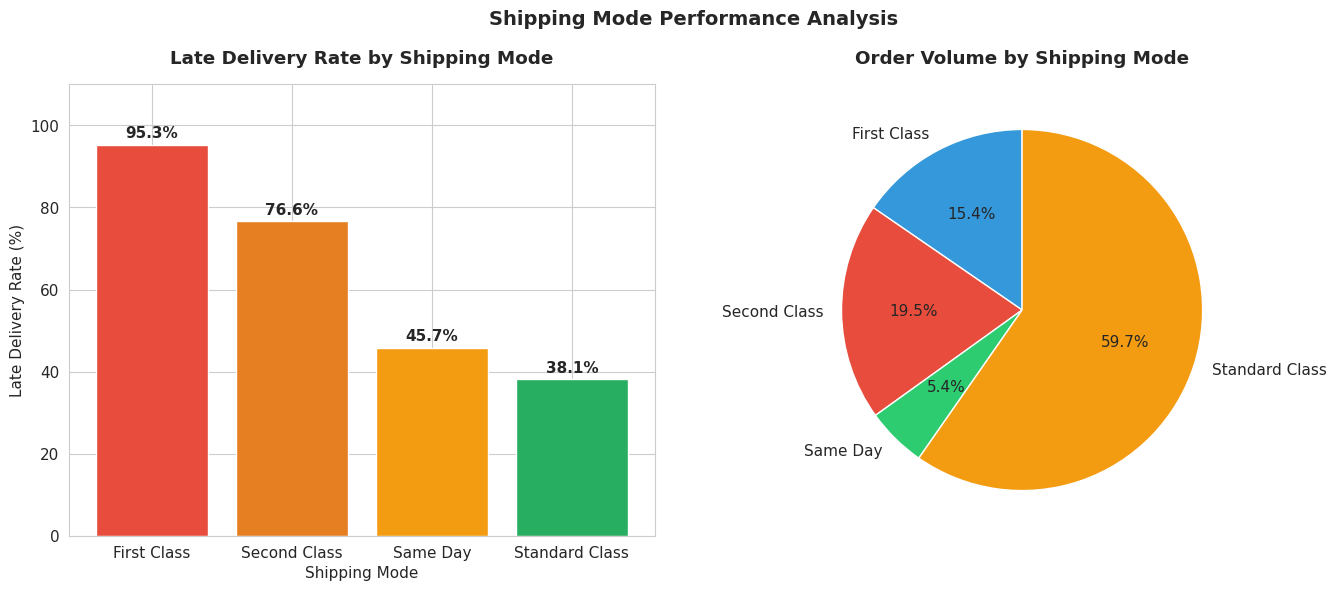

Chart 1 fixed and saved


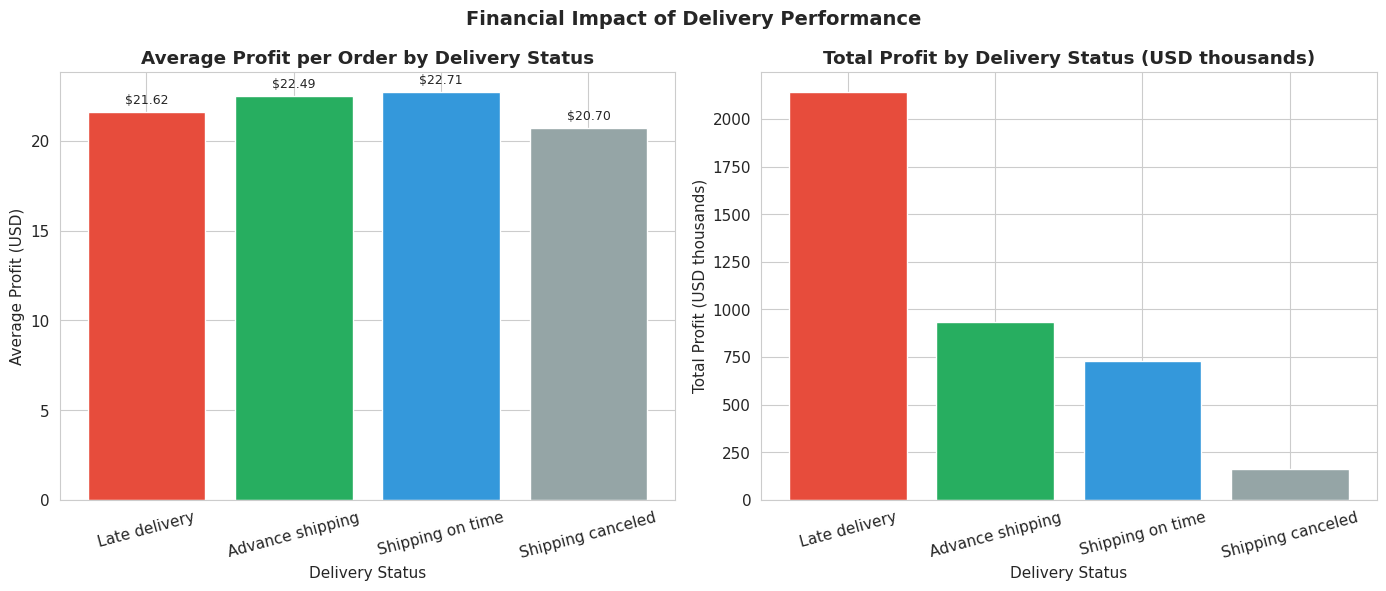

Chart 2 saved


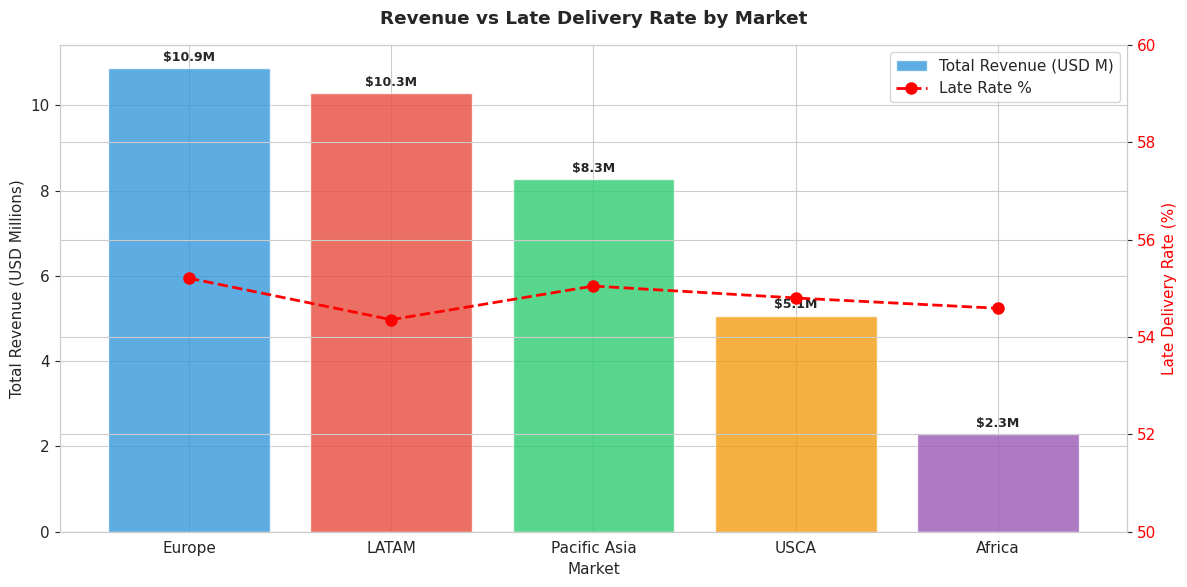

Chart 3 saved


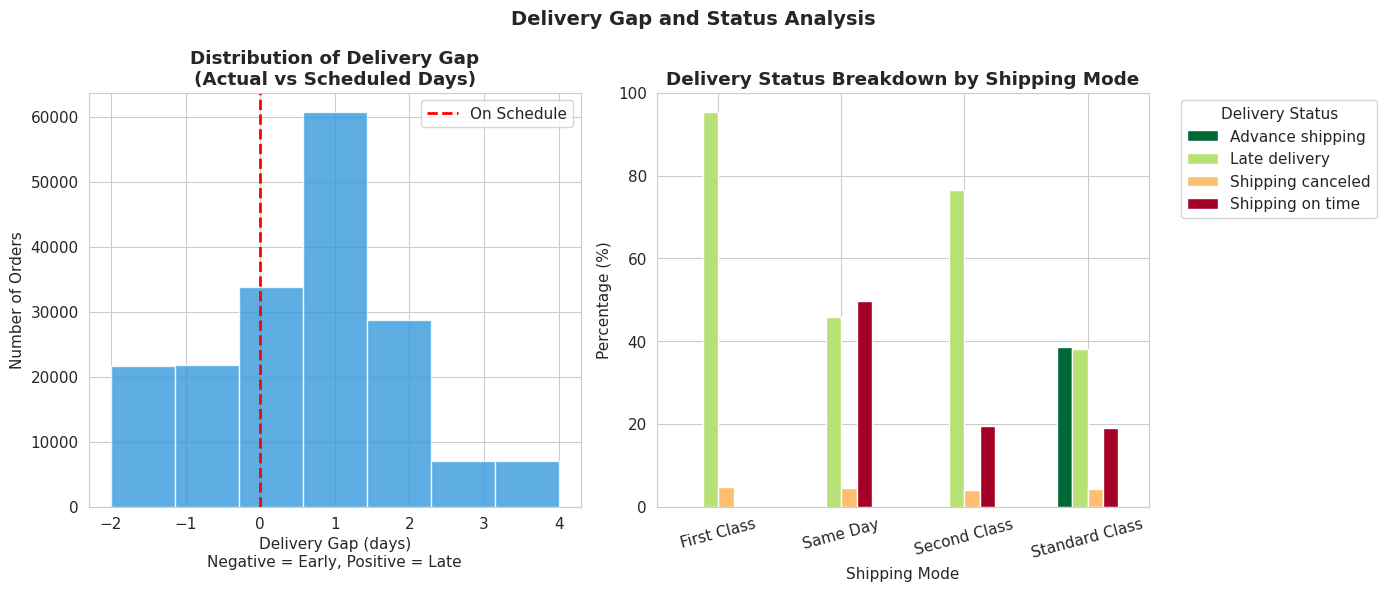

Chart 4 saved

✅ Phase 4 EDA Complete


In [ ]:
# ============================================
# PHASE 4 - EXPLORATORY DATA ANALYSIS
# ============================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
sns.set_palette("husl")

# ── CHART 1 FIXED: Late Delivery Rate by Shipping Mode ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

shipping_stats = df_clean.groupby('shipping_mode').agg(
    total_orders=('late_delivery_risk', 'count'),
    late_rate=('late_delivery_risk', 'mean')
).reset_index()
shipping_stats['late_rate_pct'] = shipping_stats['late_rate'] * 100
shipping_stats = shipping_stats.sort_values('late_rate_pct', ascending=False).reset_index(drop=True)

# Bar chart - Late rate
bar_colors = ['#E74C3C', '#E67E22', '#F39C12', '#27AE60']
bars = axes[0].bar(
    shipping_stats['shipping_mode'],
    shipping_stats['late_rate_pct'],
    color=bar_colors
)
axes[0].set_title('Late Delivery Rate by Shipping Mode', fontweight='bold', pad=15)
axes[0].set_xlabel('Shipping Mode')
axes[0].set_ylabel('Late Delivery Rate (%)')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, shipping_stats['late_rate_pct']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )

# Pie chart - Order volume
pie_colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']
axes[1].pie(
    shipping_stats['total_orders'],
    labels=shipping_stats['shipping_mode'],
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90
)
axes[1].set_title('Order Volume by Shipping Mode', fontweight='bold', pad=15)

plt.suptitle('Shipping Mode Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_shipping_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 fixed and saved")

# ── CHART 2: Financial Impact ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

financial = df_clean.groupby('delivery_status').agg(
    total_profit=('profit_per_order', 'sum'),
    avg_profit=('profit_per_order', 'mean'),
    total_orders=('profit_per_order', 'count')
).reset_index()
financial = financial.sort_values('total_profit', ascending=False)

colors = {
    'Late delivery': '#E74C3C',
    'Advance shipping': '#27AE60',
    'Shipping on time': '#3498DB',
    'Shipping canceled': '#95A5A6'
}
bar_colors = [colors.get(s, '#95A5A6') for s in financial['delivery_status']]

axes[0].bar(financial['delivery_status'], financial['avg_profit'], color=bar_colors)
axes[0].set_title('Average Profit per Order by Delivery Status', fontweight='bold')
axes[0].set_xlabel('Delivery Status')
axes[0].set_ylabel('Average Profit (USD)')
axes[0].tick_params(axis='x', rotation=15)
for i, (bar, val) in enumerate(zip(axes[0].patches, financial['avg_profit'])):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'${val:.2f}', ha='center', va='bottom', fontsize=9)

axes[1].bar(financial['delivery_status'], financial['total_profit']/1000, color=bar_colors)
axes[1].set_title('Total Profit by Delivery Status (USD thousands)', fontweight='bold')
axes[1].set_xlabel('Delivery Status')
axes[1].set_ylabel('Total Profit (USD thousands)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Financial Impact of Delivery Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_financial_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

# ── CHART 3: Market Revenue vs Late Rate ──
fig, ax = plt.subplots(figsize=(12, 6))

market_stats = df_clean.groupby('market').agg(
    total_revenue=('sales', 'sum'),
    late_rate=('late_delivery_risk', 'mean')
).reset_index()
market_stats['late_rate_pct'] = market_stats['late_rate'] * 100
market_stats = market_stats.sort_values('total_revenue', ascending=False)

x = range(len(market_stats))
bars = ax.bar(x, market_stats['total_revenue']/1e6,
              color=['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6'],
              alpha=0.8, label='Total Revenue (USD M)')

ax2 = ax.twinx()
ax2.plot(x, market_stats['late_rate_pct'], 'ro--',
         linewidth=2, markersize=8, label='Late Rate %')
ax2.set_ylabel('Late Delivery Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(50, 60)

ax.set_xticks(x)
ax.set_xticklabels(market_stats['market'])
ax.set_title('Revenue vs Late Delivery Rate by Market', fontweight='bold', pad=15)
ax.set_xlabel('Market')
ax.set_ylabel('Total Revenue (USD Millions)')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

for bar, val in zip(bars, market_stats['total_revenue']/1e6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'${val:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_market_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

# ── CHART 4: Delivery Gap Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(df_clean['delivery_gap'], bins=7,
             color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Delivery Gap\n(Actual vs Scheduled Days)',
                  fontweight='bold')
axes[0].set_xlabel('Delivery Gap (days)\nNegative = Early, Positive = Late')
axes[0].set_ylabel('Number of Orders')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='On Schedule')
axes[0].legend()

late_by_mode = df_clean.groupby(
    ['shipping_mode', 'delivery_status']
).size().unstack(fill_value=0)
late_by_mode_pct = late_by_mode.div(late_by_mode.sum(axis=1), axis=0) * 100
late_by_mode_pct.plot(kind='bar', ax=axes[1],
                      colormap='RdYlGn_r', edgecolor='white')
axes[1].set_title('Delivery Status Breakdown by Shipping Mode', fontweight='bold')
axes[1].set_xlabel('Shipping Mode')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Delivery Status',
               bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Delivery Gap and Status Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_delivery_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

print("\n✅ Phase 4 EDA Complete")

Chart 1: First Class carries a 95.3% late delivery rate yet represents only 15.4% of total order volume. Standard Class handles 59.7% of all orders with the lowest late rate at 38.1%, making it the highest-impact target for operational improvement.

Chart 2: Late delivery orders generate an average profit of USD 21.62 per order compared to USD 22.40 for on-time orders. The total profit bar for late delivery appears largest because it has the most orders, not because it is more profitable per order. This distinction is important when interpreting the right-hand chart.

Chart 3: The red dotted line is nearly flat across all five markets, confirming that late delivery is not a regional problem. Europe generates the most revenue at USD 10.9 million but has the same late delivery rate as Africa at USD 2.3 million in revenue. The problem is systemic, not geographic.

Chart 4: The majority of orders arrive exactly 1 day later than scheduled. The First Class bar on the right panel is almost entirely late delivery because its 1-day scheduled window leaves no buffer for any operational delay whatsoever.

---

## Phase 5: Predictive Modelling

This phase builds a classification model to predict whether an order will be delivered late. The primary goal is not prediction accuracy but feature importance — understanding which operational factors drive late delivery risk most strongly.

In [ ]:
# ============================================
# PHASE 5 - PREDICTIVE MODEL
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Select features for prediction
features = [
    'shipping_mode',
    'days_shipping_scheduled',
    'days_shipping_real',
    'delivery_gap',
    'market',
    'category_name',
    'customer_segment',
    'order_year',
    'order_month',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'sales',
    'product_price'
]

# Keep only available columns
available_features = [f for f in features if f in df_clean.columns]
print("Features available:", available_features)

# Step 2: Prepare data
df_model = df_clean[available_features + ['late_delivery_risk']].copy()
df_model = df_model.dropna()

# Step 3: Encode categorical variables
le = LabelEncoder()
categorical_cols = ['shipping_mode', 'market',
                    'category_name', 'customer_segment']
for col in categorical_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# Step 4: Split data
X = df_model.drop('late_delivery_risk', axis=1)
y = df_model['late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"Late delivery rate in test set: {y_test.mean()*100:.1f}%")

Features available: ['shipping_mode', 'days_shipping_scheduled', 'days_shipping_real', 'delivery_gap', 'market', 'category_name', 'customer_segment', 'order_year', 'order_month', 'Order Item Quantity', 'Order Item Discount Rate', 'sales', 'product_price']

Training set: 144,415 rows
Test set: 36,104 rows
Late delivery rate in test set: 54.8%


In [ ]:
# Step 5: Train Logistic Regression (Baseline)
print("Training Logistic Regression baseline model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])

print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"AUC Score: {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['On Time', 'Late Delivery']))

# Step 6: Train Random Forest (Final Model)
print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"AUC Score: {rf_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['On Time', 'Late Delivery']))

# Step 7: Compare models
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"Winner: {'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'}")

Training Logistic Regression baseline model...

LOGISTIC REGRESSION RESULTS
AUC Score: 0.9725

Classification Report:
               precision    recall  f1-score   support

      On Time       1.00      0.94      0.97     16308
Late Delivery       0.96      1.00      0.98     19796

     accuracy                           0.97     36104
    macro avg       0.98      0.97      0.97     36104
 weighted avg       0.98      0.97      0.97     36104


Training Random Forest model...

RANDOM FOREST RESULTS
AUC Score: 0.9758

Classification Report:
               precision    recall  f1-score   support

      On Time       1.00      0.94      0.97     16308
Late Delivery       0.96      1.00      0.98     19796

     accuracy                           0.97     36104
    macro avg       0.98      0.97      0.97     36104
 weighted avg       0.98      0.97      0.97     36104


MODEL COMPARISON
Logistic Regression AUC: 0.9725
Random Forest AUC:       0.9758
Winner: Random Forest


Random Forest is selected as the final model with an AUC score of 0.9758 compared to 0.9725 for Logistic Regression. Both models achieve 97% accuracy on the test set.

Note on model limitations: The two most important features, delivery gap and actual shipping days, are only known after delivery has occurred. In a production environment the model should be retrained using only pre-shipment features such as shipping mode and scheduled days. The current model is best suited to retrospective analysis rather than real-time prediction.

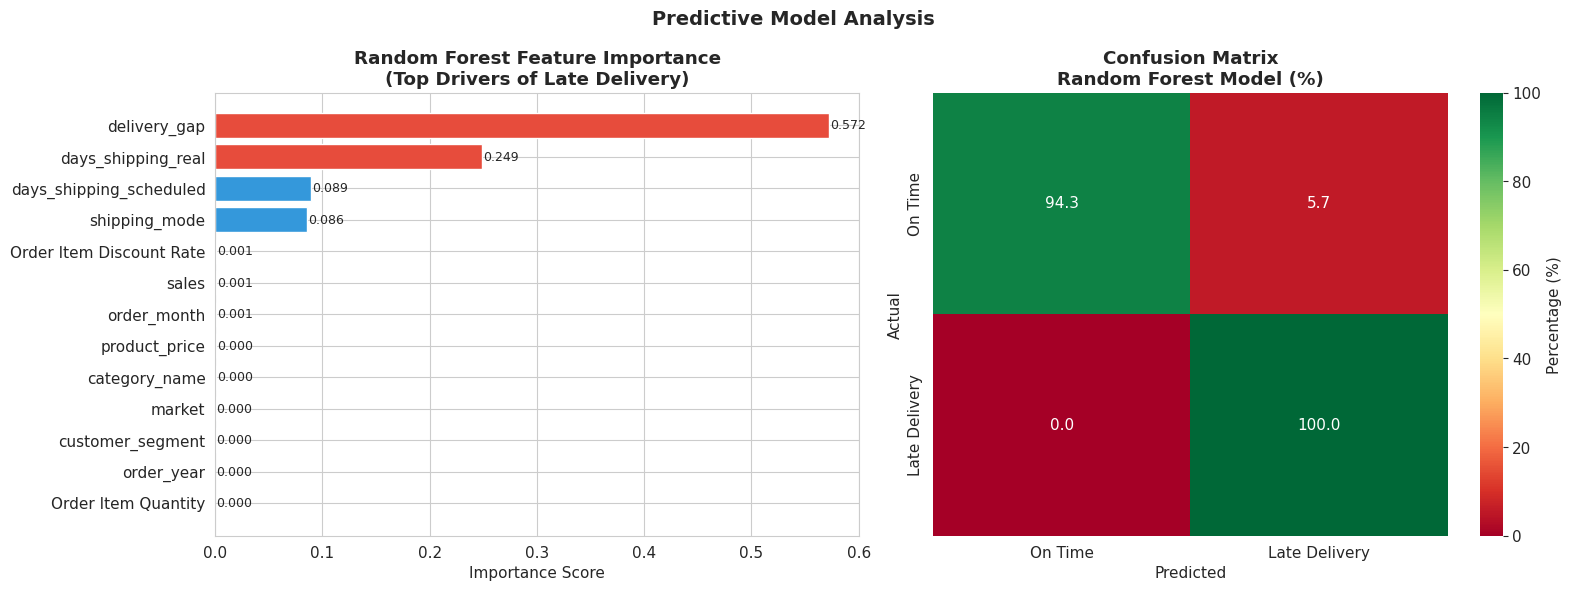

Chart 5 saved

TOP 5 FEATURES DRIVING LATE DELIVERY RISK
1. delivery_gap: 0.572
2. days_shipping_real: 0.249
3. days_shipping_scheduled: 0.089
4. shipping_mode: 0.086
5. Order Item Discount Rate: 0.001


In [ ]:
# Step 8: Feature Importance Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#E74C3C' if imp > 0.1 else '#3498DB'
          for imp in feature_importance['importance']]

axes[0].barh(feature_importance['feature'],
             feature_importance['importance'],
             color=colors)
axes[0].set_title('Random Forest Feature Importance\n(Top Drivers of Late Delivery)',
                  fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, (val, name) in enumerate(zip(feature_importance['importance'],
                                     feature_importance['feature'])):
    axes[0].text(val + 0.001, i, f'{val:.3f}',
                va='center', fontsize=9)

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=['On Time', 'Late Delivery'],
            yticklabels=['On Time', 'Late Delivery'],
            ax=axes[1], cbar_kws={'label': 'Percentage (%)'})
axes[1].set_title('Confusion Matrix\nRandom Forest Model (%)',
                  fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Predictive Model Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

# Step 9: Print top features with business interpretation
print("\n" + "="*50)
print("TOP 5 FEATURES DRIVING LATE DELIVERY RISK")
print("="*50)
top5 = feature_importance.tail(5).iloc[::-1]
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"{i}. {row['feature']}: {row['importance']:.3f}")

The top four predictive features are all scheduling related: delivery gap, actual shipping days, scheduled shipping days, and shipping mode. Product category, market, customer segment, and order value have near-zero importance.

This confirms the core finding of the entire analysis. Late delivery is driven entirely by scheduling decisions, not by what is being shipped, where it is going, or who is ordering it.

---

## Summary

This analysis identified three key findings:

1. First Class shipping carries a 95.3% late delivery rate caused by an unrealistic 1-day scheduled window
2. Late delivery rates are consistent across all five global markets, confirming a systemic scheduling issue
3. Late deliveries cost the business approximately 77,000 dollars in avoidable profit loss

The interactive Tableau dashboard presenting these findings is available at the link in the README.

In [ ]:
from google.colab import files

# Download clean dataset for Tableau
files.download('supply_chain_clean.csv')

# Download all charts
files.download('chart1_shipping_mode.png')
files.download('chart2_financial_impact.png')
files.download('chart3_market_analysis.png')
files.download('chart4_delivery_gap.png')
files.download('chart5_model_results.png')

print("All files downloaded successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded successfully
